In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/nextgen_nlp_final")
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

NER_INPUT_PATH = ARTIFACTS_DIR / "ner_input_articles.parquet"

df_ner = pd.read_parquet(NER_INPUT_PATH)

print("Shape:", df_ner.shape)
df_ner.head()

Shape: (33765, 6)


,date,title_clean,clean_text,topic,topic_name,industry_label
0,2024-03-13 00:00:00+00:00,Best AI Prompts for Business Risk Management,ManagementPrompt: Identify and prioritize pote...,4,AI cybersecurity,Cybersecurity
1,2023-07-26 00:00:00+00:00,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,"July 26, 2023 Finance Bullfrog AI Holdings Inc...",0,AI chips and GPUs,AI Infrastructure
2,2025-01-17 00:00:00+00:00,4 Principles to Help Federal Agencies Adopt AI...,"Source: SolarWinds, “Navigating the AI Revolut...",4,AI cybersecurity,Cybersecurity
3,2024-02-13 00:00:00+00:00,2 Artificial Intelligence (AI) Stocks to Buy a...,"February 13, 2024 at 9:13 AM·4 min readArtific...",0,AI chips and GPUs,AI Infrastructure
4,2022-11-09 00:00:00+00:00,Silicon Photonics Market to Present Revenue Op...,"November 9, 2022, 9:02 AM·5 min readSkyQuest T...",0,AI chips and GPUs,AI Infrastructure


In [3]:
df_ner.columns

Index(['date', 'title_clean', 'clean_text', 'topic', 'topic_name',
       'industry_label'],
      dtype='object')

In [4]:
df_ner["clean_text"].isna().sum()

np.int64(0)

Step 4 — 合并 title + text

In [5]:
df_ner["ner_text"] = (
    df_ner["title_clean"].fillna("") + ". " +
    df_ner["clean_text"].fillna("")
)

In [6]:
df_ner["ner_text"].str.len().describe()

,ner_text
count,33765.000000
mean,6390.176011
std,4201.451007
min,343.000000
25%,3765.000000
50%,5575.000000
75%,8053.000000
max,48311.000000


In [7]:
df_ner["ner_text"] = df_ner["ner_text"].str[:3000]

In [8]:
df_ner["industry_label"].value_counts()

,count
industry_label,
AI Infrastructure,8088
Healthcare,5113
Enterprise IT,3065
AI Governance / Risk,2627
Government / Regulation,2437
Cybersecurity,2203
Finance,1871
Transportation,1553
Consumer Electronics,1548


In [9]:
NER_WORKING_PATH = ARTIFACTS_DIR / "ner_working_input.parquet"

df_ner.to_parquet(NER_WORKING_PATH, index=False)

print("Saved:", NER_WORKING_PATH)

Saved: /content/drive/MyDrive/nextgen_nlp_final/artifacts/ner_working_input.parquet


## 开始做

In [18]:
!pip install -q transformers accelerate torch

In [19]:
from transformers import pipeline
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")

ner_pipe = pipeline(
    "token-classification",
    model="Jean-Baptiste/roberta-large-ner-english",
    aggregation_strategy="simple",
    device=0
)

True
NVIDIA A100-SXM4-80GB


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/849 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

RobertaForTokenClassification LOAD REPORT from: Jean-Baptiste/roberta-large-ner-english
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [23]:
import pandas as pd
import re

records = []

texts = df_ner["ner_text"].fillna("").astype(str).str[:2000].tolist()
chunk_size = 512
batch_size = 32

for start in range(0, len(texts), chunk_size):
    end = min(start + chunk_size, len(texts))

    text_chunk = texts[start:end]
    row_chunk = df_ner.iloc[start:end]

    ner_outputs = ner_pipe(
        text_chunk,
        batch_size=batch_size
    )

    for j, ents in enumerate(ner_outputs):
        row = row_chunk.iloc[j]

        for ent in ents:
            if ent["entity_group"] == "ORG":
                entity_text = ent["word"].strip()
                entity_text = re.sub(r"\s+", " ", entity_text)
                entity_text = entity_text.strip(" .,;:|()[]{}\"'")

                if len(entity_text) >= 2:
                    records.append({
                        "date": row["date"],
                        "topic": row["topic"],
                        "topic_name": row["topic_name"],
                        "industry_label": row["industry_label"],
                        "title_clean": row["title_clean"],
                        "entity_text": entity_text,
                        "entity_label": ent["entity_group"],
                        "score": ent["score"]
                    })

    print(f"processed: {start} -> {end}")

df_entities = pd.DataFrame(records)

print(df_entities.shape)
df_entities.head(20)

processed: 0 -> 512
processed: 512 -> 1024
processed: 1024 -> 1536
processed: 1536 -> 2048
processed: 2048 -> 2560
processed: 2560 -> 3072
processed: 3072 -> 3584
processed: 3584 -> 4096
processed: 4096 -> 4608
processed: 4608 -> 5120
processed: 5120 -> 5632
processed: 5632 -> 6144
processed: 6144 -> 6656
processed: 6656 -> 7168
processed: 7168 -> 7680
processed: 7680 -> 8192
processed: 8192 -> 8704
processed: 8704 -> 9216
processed: 9216 -> 9728
processed: 9728 -> 10240
processed: 10240 -> 10752
processed: 10752 -> 11264
processed: 11264 -> 11776
processed: 11776 -> 12288
processed: 12288 -> 12800
processed: 12800 -> 13312
processed: 13312 -> 13824
processed: 13824 -> 14336
processed: 14336 -> 14848
processed: 14848 -> 15360
processed: 15360 -> 15872
processed: 15872 -> 16384
processed: 16384 -> 16896
processed: 16896 -> 17408
processed: 17408 -> 17920
processed: 17920 -> 18432
processed: 18432 -> 18944
processed: 18944 -> 19456
processed: 19456 -> 19968
processed: 19968 -> 20480
proc

,date,topic,topic_name,industry_label,title_clean,entity_text,entity_label,score
0,2023-07-26 00:00:00+00:00,0,AI chips and GPUs,AI Infrastructure,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,Bullfrog AI Holdings Inc,ORG,0.999630
1,2023-07-26 00:00:00+00:00,0,AI chips and GPUs,AI Infrastructure,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,BFRG,ORG,0.982130
2,2023-07-26 00:00:00+00:00,0,AI chips and GPUs,AI Infrastructure,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,The DBT News,ORG,0.992576
3,2023-07-26 00:00:00+00:00,0,AI chips and GPUs,AI Infrastructure,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,Bullfrog AI Holdings Inc,ORG,0.999625
4,2023-07-26 00:00:00+00:00,0,AI chips and GPUs,AI Infrastructure,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,BFRG,ORG,0.861583
5,2023-07-26 00:00:00+00:00,0,AI chips and GPUs,AI Infrastructure,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,BullFrog AI,ORG,0.999553
6,2023-07-26 00:00:00+00:00,0,AI chips and GPUs,AI Infrastructure,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,Grand View Re,ORG,0.999327
7,2023-07-26 00:00:00+00:00,0,AI chips and GPUs,AI Infrastructure,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,Bullfrog AI Holdings Inc,ORG,0.999659
8,2023-07-26 00:00:00+00:00,0,AI chips and GPUs,AI Infrastructure,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,Bullfrog AI Holdings Inc,ORG,0.999641
9,2023-07-26 00:00:00+00:00,0,AI chips and GPUs,AI Infrastructure,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,BFRG,ORG,0.983758


In [24]:
ENTITIES_RAW_PATH = ARTIFACTS_DIR / "entities_raw.parquet"

df_entities.to_parquet(ENTITIES_RAW_PATH, index=False)

print("Saved:", ENTITIES_RAW_PATH)
print("Rows:", len(df_entities))

Saved: /content/drive/MyDrive/nextgen_nlp_final/artifacts/entities_raw.parquet
Rows: 387787


In [25]:
df_entities["entity_text"].value_counts().head(30)

,count
entity_text,
OpenAI,15184
Apple,11396
Nvidia,10043
Microsoft,9313
Google,7009
PRNewswire,3632
AMD,3063
Intel,2426
Meta,2262


In [26]:
industry_company_counts = (
    df_entities
    .groupby(["industry_label", "entity_text"])
    .size()
    .reset_index(name="count")
    .sort_values(["industry_label", "count"], ascending=[True, False])
)

industry_company_counts.head(30)

,industry_label,entity_text,count
2879,AI Governance / Risk,OpenAI,7386
2429,AI Governance / Risk,Microsoft,2174
1648,AI Governance / Risk,Google,654
118,AI Governance / Risk,AP,330
268,AI Governance / Risk,Anthropic,297
282,AI Governance / Risk,Apple,229
2600,AI Governance / Risk,NPR,215
1596,AI Governance / Risk,Getty Images,212
4175,AI Governance / Risk,Twitter,204
847,AI Governance / Risk,ChatGPT,201


In [27]:
COMPANY_COUNTS_PATH = ARTIFACTS_DIR / "industry_company_counts.csv"

industry_company_counts.to_csv(COMPANY_COUNTS_PATH, index=False)

print("Saved:", COMPANY_COUNTS_PATH)

Saved: /content/drive/MyDrive/nextgen_nlp_final/artifacts/industry_company_counts.csv


In [28]:
import pandas as pd
import re

ENTITIES_RAW_PATH = ARTIFACTS_DIR / "entities_raw.parquet"

df_entities = pd.read_parquet(ENTITIES_RAW_PATH)

print(df_entities.shape)
df_entities.head()

(387787, 8)


,date,topic,topic_name,industry_label,title_clean,entity_text,entity_label,score
0,2023-07-26 00:00:00+00:00,0,AI chips and GPUs,AI Infrastructure,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,Bullfrog AI Holdings Inc,ORG,0.999630
1,2023-07-26 00:00:00+00:00,0,AI chips and GPUs,AI Infrastructure,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,BFRG,ORG,0.982130
2,2023-07-26 00:00:00+00:00,0,AI chips and GPUs,AI Infrastructure,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,The DBT News,ORG,0.992576
3,2023-07-26 00:00:00+00:00,0,AI chips and GPUs,AI Infrastructure,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,Bullfrog AI Holdings Inc,ORG,0.999625
4,2023-07-26 00:00:00+00:00,0,AI chips and GPUs,AI Infrastructure,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,BFRG,ORG,0.861583


In [29]:
CORP_SUFFIXES = [
    "inc", "inc.", "corp", "corp.", "corporation",
    "ltd", "ltd.", "llc", "plc",
    "group", "holdings", "holding",
    "co", "co.", "company"
]

def normalize_company(name):

    name = str(name)

    # remove punctuation
    name = re.sub(r"[^\w\s]", " ", name)

    # lowercase
    name = name.lower()

    words = name.split()

    words = [w for w in words if w not in CORP_SUFFIXES]

    name = " ".join(words)

    # title case
    name = name.title()

    return name.strip()

In [30]:
df_entities["company"] = df_entities["entity_text"].apply(normalize_company)

df_entities.head()

,date,topic,topic_name,industry_label,title_clean,entity_text,entity_label,score,company
0,2023-07-26 00:00:00+00:00,0,AI chips and GPUs,AI Infrastructure,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,Bullfrog AI Holdings Inc,ORG,0.999630,Bullfrog Ai
1,2023-07-26 00:00:00+00:00,0,AI chips and GPUs,AI Infrastructure,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,BFRG,ORG,0.982130,Bfrg
2,2023-07-26 00:00:00+00:00,0,AI chips and GPUs,AI Infrastructure,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,The DBT News,ORG,0.992576,The Dbt News
3,2023-07-26 00:00:00+00:00,0,AI chips and GPUs,AI Infrastructure,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,Bullfrog AI Holdings Inc,ORG,0.999625,Bullfrog Ai
4,2023-07-26 00:00:00+00:00,0,AI chips and GPUs,AI Infrastructure,Bullfrog AI Holdings Inc. [BFRG] Revenue clock...,BFRG,ORG,0.861583,Bfrg


In [31]:
df_entities = df_entities[
    df_entities["company"].str.len() > 2
]

df_entities = df_entities[
    ~df_entities["company"].str.contains("Ai$", case=False)
]

In [32]:
company_counts = (
    df_entities
    .groupby(["industry_label", "company"])
    .size()
    .reset_index(name="count")
    .sort_values(["industry_label", "count"], ascending=[True, False])
)

company_counts.head(20)

,industry_label,company,count
2422,AI Governance / Risk,Microsoft,2207
1630,AI Governance / Risk,Google,655
230,AI Governance / Risk,Anthropic,298
254,AI Governance / Risk,Apple,240
2789,AI Governance / Risk,Npr,230
1571,AI Governance / Risk,Getty Images,217
4174,AI Governance / Risk,Twitter,205
779,AI Governance / Risk,Chatgpt,203
3239,AI Governance / Risk,Reuters,199
2389,AI Governance / Risk,Meta,193


In [33]:
top_companies = (
    company_counts
    .groupby("industry_label")
    .head(10)
    .reset_index(drop=True)
)

top_companies

,industry_label,company,count
0,AI Governance / Risk,Microsoft,2207
1,AI Governance / Risk,Google,655
2,AI Governance / Risk,Anthropic,298
3,AI Governance / Risk,Apple,240
4,AI Governance / Risk,Npr,230
...,...,...,...
125,Transportation,Google Cloud,177
126,Transportation,Ai Online,161
127,Transportation,Nvidia,158
128,Transportation,Google,138


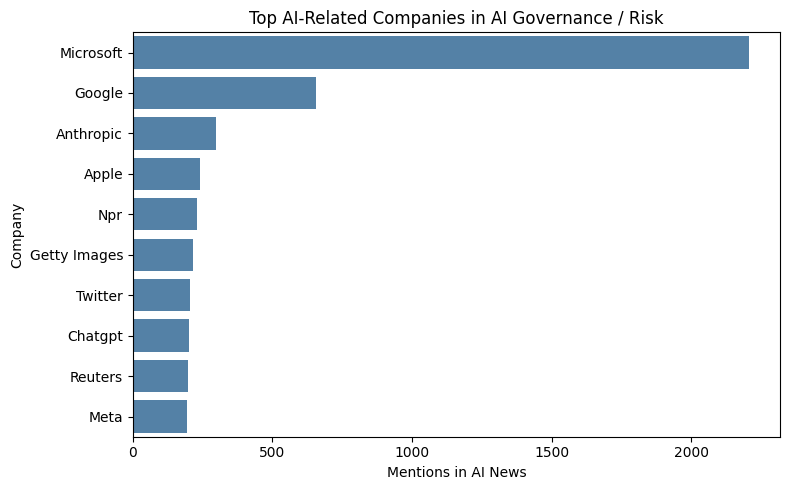

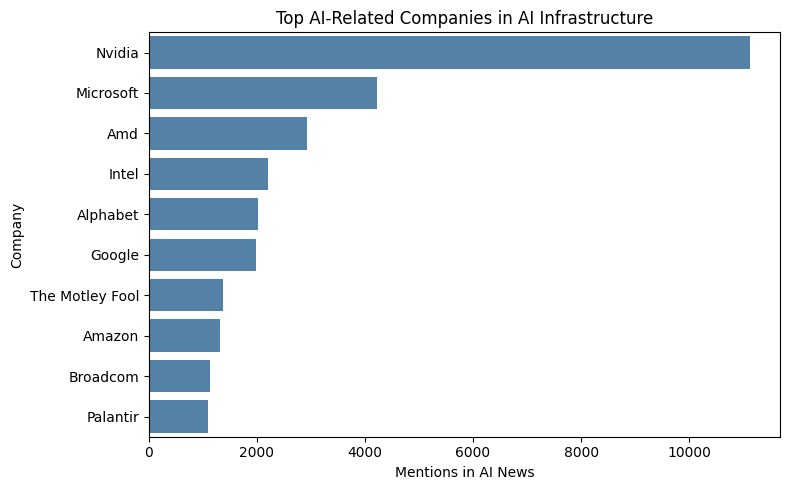

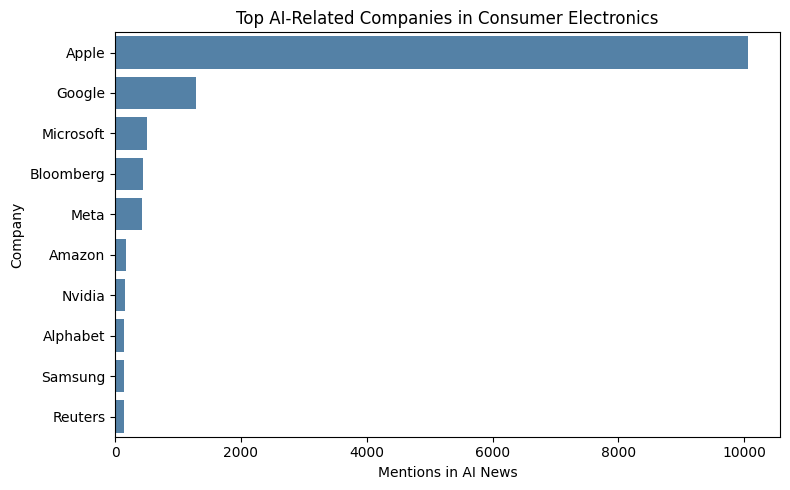

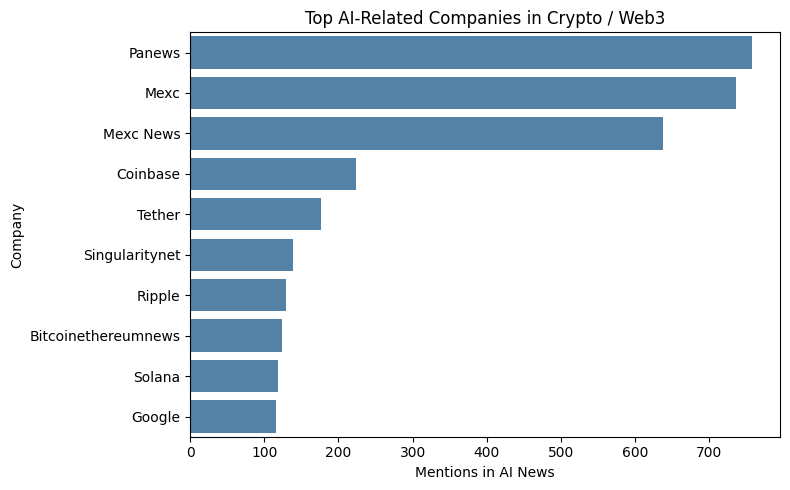

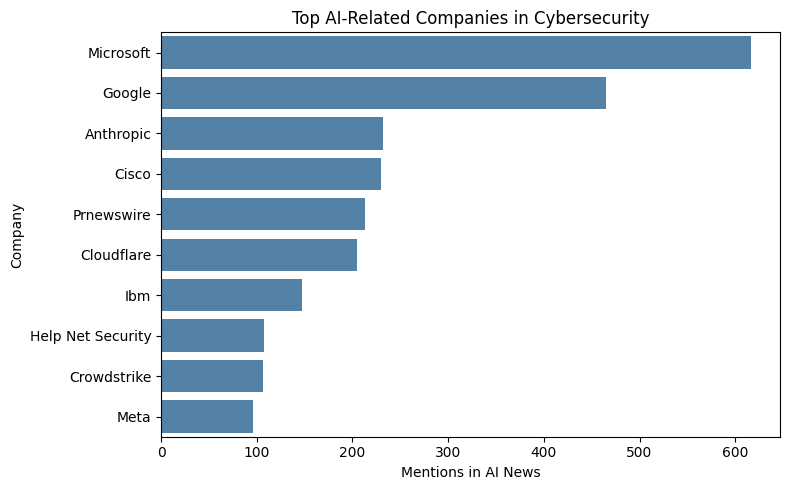

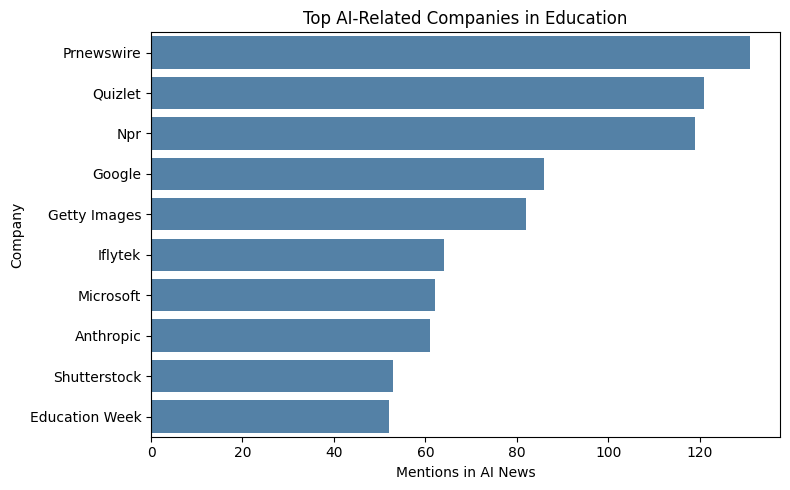

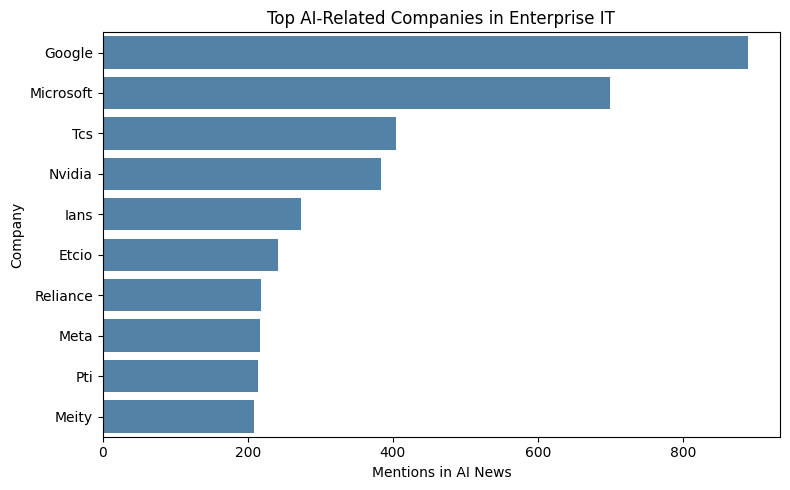

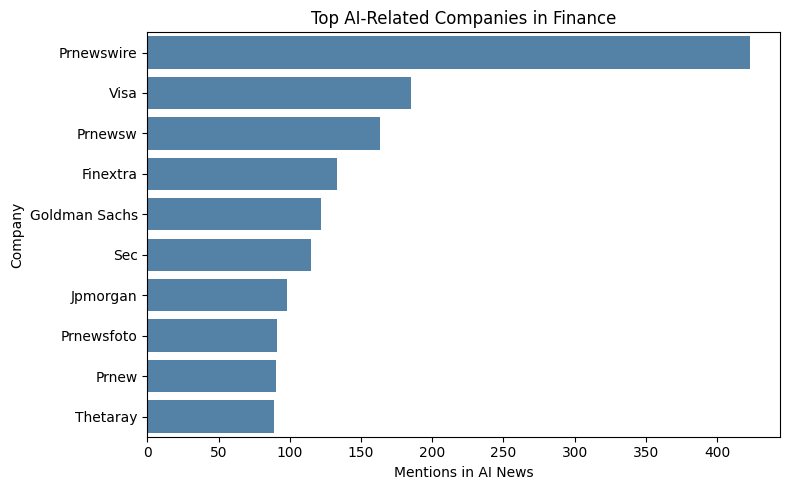

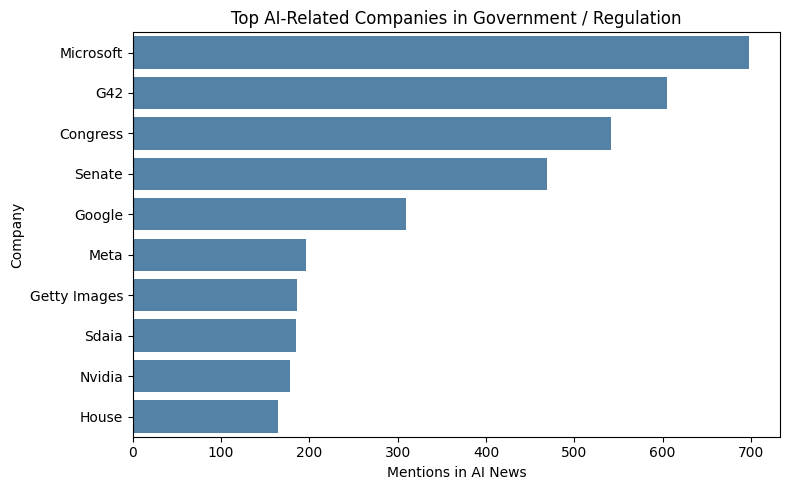

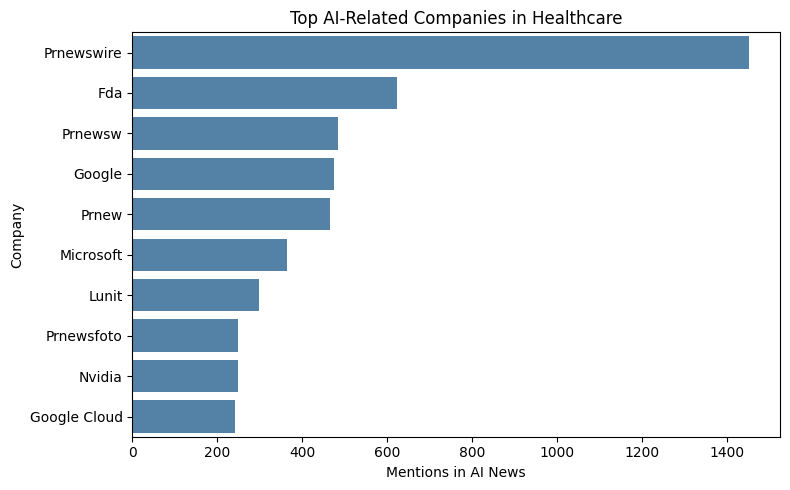

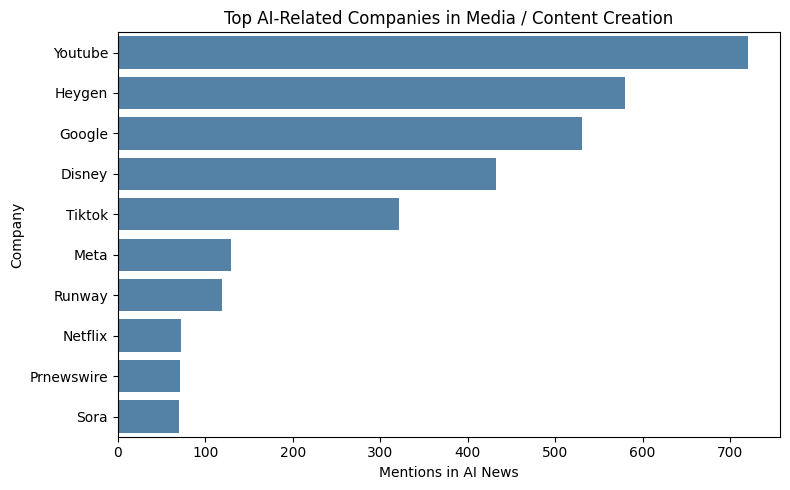

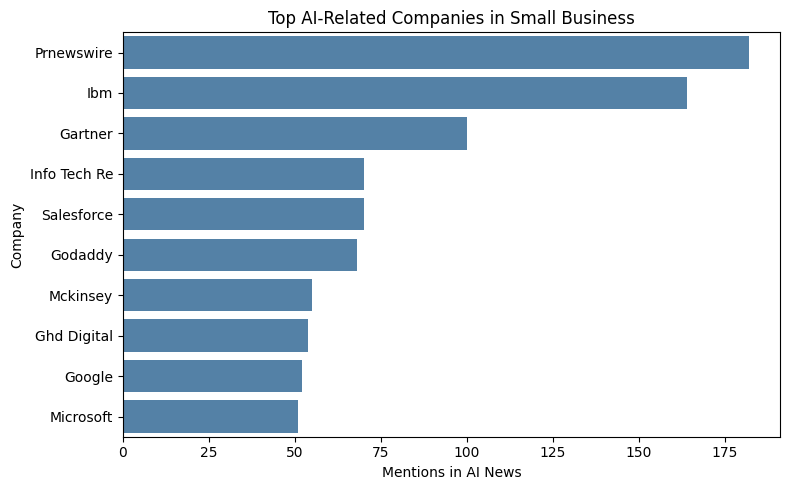

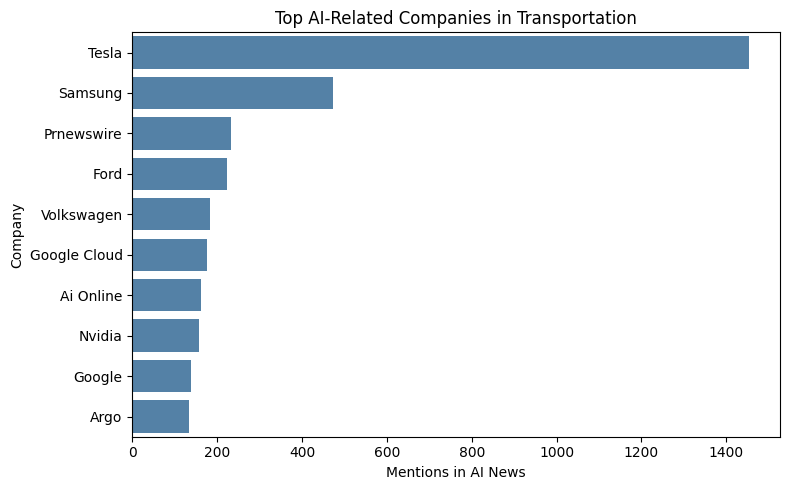

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

industries = top_companies["industry_label"].unique()

for ind in industries:

    df_plot = top_companies[top_companies["industry_label"] == ind]

    plt.figure(figsize=(8,5))

    sns.barplot(
        data=df_plot,
        x="count",
        y="company",
        color="steelblue"
    )

    plt.title(f"Top AI-Related Companies in {ind}")
    plt.xlabel("Mentions in AI News")
    plt.ylabel("Company")

    plt.tight_layout()
    plt.show()

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import re
from pathlib import Path

FIG_DIR = ARTIFACTS_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

industries = top_companies["industry_label"].unique()

for ind in industries:

    df_plot = top_companies[top_companies["industry_label"] == ind]

    plt.figure(figsize=(8,5))

    sns.barplot(
        data=df_plot,
        x="count",
        y="company",
        color="steelblue"
    )

    plt.title(f"Top AI-Related Companies in {ind}")
    plt.xlabel("Mentions in AI News")
    plt.ylabel("Company")

    plt.tight_layout()

    # 清理文件名
    safe_name = re.sub(r"[^\w\s-]", "", ind).replace(" ", "_")

    save_path = FIG_DIR / f"top_companies_{safe_name}.png"

    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.close()

    print("Saved:", save_path)

Saved: /content/drive/MyDrive/nextgen_nlp_final/artifacts/figures/top_companies_AI_Governance__Risk.png
Saved: /content/drive/MyDrive/nextgen_nlp_final/artifacts/figures/top_companies_AI_Infrastructure.png
Saved: /content/drive/MyDrive/nextgen_nlp_final/artifacts/figures/top_companies_Consumer_Electronics.png
Saved: /content/drive/MyDrive/nextgen_nlp_final/artifacts/figures/top_companies_Crypto__Web3.png
Saved: /content/drive/MyDrive/nextgen_nlp_final/artifacts/figures/top_companies_Cybersecurity.png
Saved: /content/drive/MyDrive/nextgen_nlp_final/artifacts/figures/top_companies_Education.png
Saved: /content/drive/MyDrive/nextgen_nlp_final/artifacts/figures/top_companies_Enterprise_IT.png
Saved: /content/drive/MyDrive/nextgen_nlp_final/artifacts/figures/top_companies_Finance.png
Saved: /content/drive/MyDrive/nextgen_nlp_final/artifacts/figures/top_companies_Government__Regulation.png
Saved: /content/drive/MyDrive/nextgen_nlp_final/artifacts/figures/top_companies_Healthcare.png
Saved: /